In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import learning_curve, validation_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")    
plt.rcParams['figure.figsize'] = (12, 6)
os.makedirs('./reports', exist_ok=True)

import os
os.makedirs('../reports', exist_ok=True)

print("Libraries imported successfully ")

Libraries imported successfully 


In [ ]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

best_model      = joblib.load('../models/best_model.pkl')
best_model_name = joblib.load('../models/best_model_name.pkl')
feature_names   = joblib.load('../models/feature_names.pkl')

print(f"Data loaded ")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"\n Best Model: {best_model_name}")


train_acc = accuracy_score(y_train, best_model.predict(X_train))
test_acc  = accuracy_score(y_test,  best_model.predict(X_test))
print(f"\nCurrent Performance: ")
print(f"  Train Accuracy : {train_acc*100:.2f}%")
print(f"  Test  Accuracy : {test_acc*100:.2f}%")
print(f"  Gap            : {(train_acc - test_acc)*100:.2f}%")
print()
if train_acc - test_acc > 0.10:
    print(" Gap > 10% → Possible OVERFITTING detected!")
elif test_acc < 0.75:
    print(" Test accuracy < 75% → Possible UNDERFITTING!")
else:
    print("Model looks well-fitted!")

Data loaded 
X_train : (800, 12)
X_test  : (154, 12)

 Best Model: Decision Tree

Current Performance:
  Train Accuracy : 93.75%
  Test  Accuracy : 88.31%
  Gap            : 5.44%

Model looks well-fitted!


In [5]:
# Apply fixes for overfitting on key models

print("=" * 55)
print("   Applying Overfitting Fixes")
print("=" * 55)

fixes = {}

dt_overfit  = DecisionTreeClassifier(random_state=42)              
dt_pruned   = DecisionTreeClassifier(max_depth=best_depth,
                                      random_state=42)              

dt_overfit.fit(X_train, y_train)
dt_pruned.fit(X_train, y_train)

print(f"\n  Decision Tree Pruning:")
print(f"   Without pruning → Train: {dt_overfit.score(X_train,y_train)*100:.2f}%  "
      f"Test: {dt_overfit.score(X_test,y_test)*100:.2f}%  "
      f"Gap: {(dt_overfit.score(X_train,y_train)-dt_overfit.score(X_test,y_test))*100:.2f}%")
print(f"   With pruning    → Train: {dt_pruned.score(X_train,y_train)*100:.2f}%  "
      f"Test: {dt_pruned.score(X_test,y_test)*100:.2f}%  "
      f"Gap: {(dt_pruned.score(X_train,y_train)-dt_pruned.score(X_test,y_test))*100:.2f}%")
fixes['DT Unpruned'] = (dt_overfit.score(X_train,y_train), dt_overfit.score(X_test,y_test))
fixes['DT Pruned']   = (dt_pruned.score(X_train,y_train),  dt_pruned.score(X_test,y_test))

lr_no_reg = LogisticRegression(C=1000, max_iter=1000, random_state=42)  
lr_reg    = LogisticRegression(C=0.1,  max_iter=1000, random_state=42)  

lr_no_reg.fit(X_train, y_train)
lr_reg.fit(X_train, y_train)

print(f"\n  Logistic Regression Regularization:")
print(f"   Weak   (C=1000) → Train: {lr_no_reg.score(X_train,y_train)*100:.2f}%  "
      f"Test: {lr_no_reg.score(X_test,y_test)*100:.2f}%")
print(f"   Strong (C=0.1)  → Train: {lr_reg.score(X_train,y_train)*100:.2f}%  "
      f"Test: {lr_reg.score(X_test,y_test)*100:.2f}%")
fixes['LR Weak Reg']   = (lr_no_reg.score(X_train,y_train), lr_no_reg.score(X_test,y_test))
fixes['LR Strong Reg'] = (lr_reg.score(X_train,y_train),    lr_reg.score(X_test,y_test))


xgb_complex = XGBClassifier(n_estimators=500, max_depth=8,
                              learning_rate=0.3, eval_metric='logloss',
                              random_state=42)
xgb_tuned   = XGBClassifier(n_estimators=100, max_depth=4,
                              learning_rate=0.1, eval_metric='logloss',
                              subsample=0.8,    
                              colsample_bytree=0.8,  
                              random_state=42)

xgb_complex.fit(X_train, y_train)
xgb_tuned.fit(X_train, y_train)

print(f"\n  XGBoost Complexity Control:")
print(f"   Overcomplex → Train: {xgb_complex.score(X_train,y_train)*100:.2f}%  "
      f"Test: {xgb_complex.score(X_test,y_test)*100:.2f}%  "
      f"Gap: {(xgb_complex.score(X_train,y_train)-xgb_complex.score(X_test,y_test))*100:.2f}%")
print(f"   Tuned       → Train: {xgb_tuned.score(X_train,y_train)*100:.2f}%  "
      f"Test: {xgb_tuned.score(X_test,y_test)*100:.2f}%  "
      f"Gap: {(xgb_tuned.score(X_train,y_train)-xgb_tuned.score(X_test,y_test))*100:.2f}%")
fixes['XGB Overcomplex'] = (xgb_complex.score(X_train,y_train), xgb_complex.score(X_test,y_test))
fixes['XGB Tuned']       = (xgb_tuned.score(X_train,y_train),   xgb_tuned.score(X_test,y_test))

   Applying Overfitting Fixes

  Decision Tree Pruning:
   Without pruning → Train: 100.00%  Test: 87.01%  Gap: 12.99%
   With pruning    → Train: 90.00%  Test: 87.66%  Gap: 2.34%

  Logistic Regression Regularization:
   Weak   (C=1000) → Train: 82.12%  Test: 76.62%
   Strong (C=0.1)  → Train: 81.62%  Test: 77.92%

  XGBoost Complexity Control:
   Overcomplex → Train: 100.00%  Test: 87.66%  Gap: 12.34%
   Tuned       → Train: 99.75%  Test: 88.31%  Gap: 11.44%


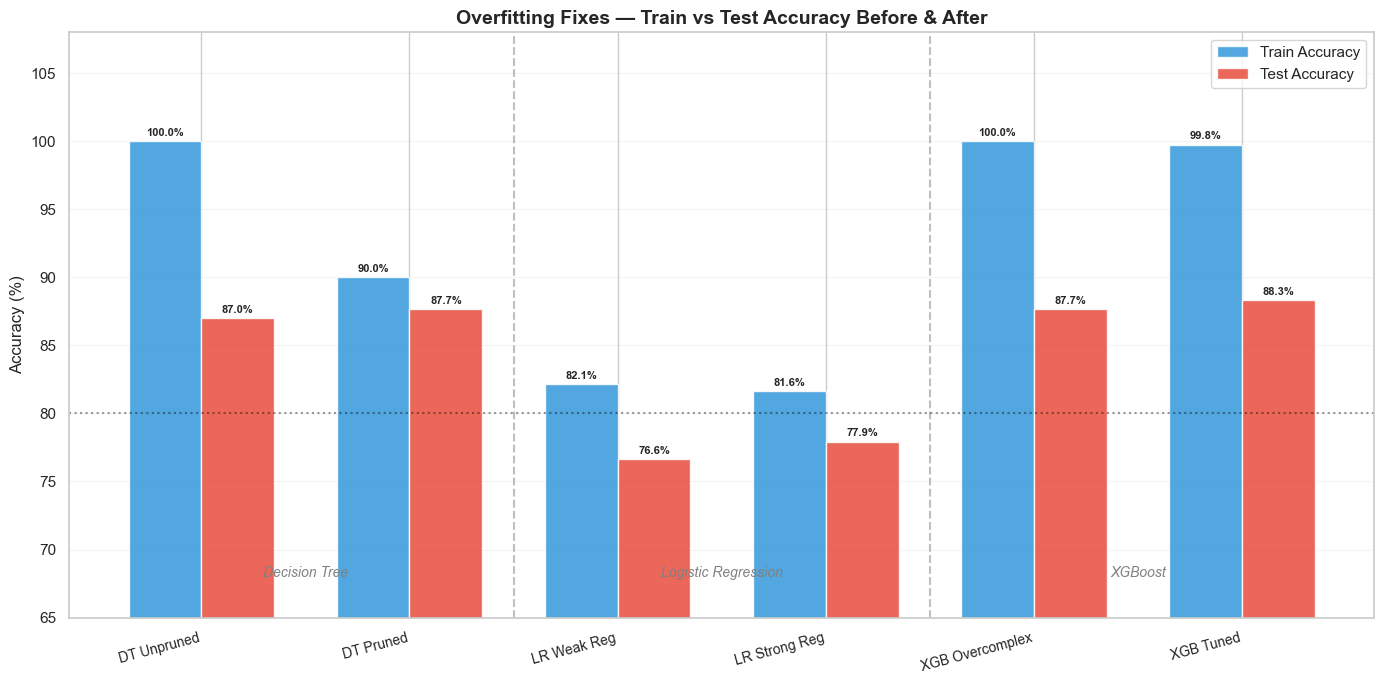

 Plot saved to reports/17_overfitting_fixes.png


In [6]:
# PLOT: Before vs After overfitting fixes

fig, ax = plt.subplots(figsize=(14, 7))

models_list = list(fixes.keys())
train_accs  = [fixes[m][0] * 100 for m in models_list]
test_accs   = [fixes[m][1] * 100 for m in models_list]

x     = np.arange(len(models_list))
width = 0.35

bars1 = ax.bar(x - width/2, train_accs, width,
               label='Train Accuracy', color='#3498db',
               edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + width/2, test_accs, width,
               label='Test Accuracy', color='#e74c3c',
               edgecolor='white', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')

# Add vertical separators between model pairs
ax.axvline(x=1.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.5)

# Add group labels
ax.text(0.5, 68, 'Decision Tree', ha='center', fontsize=10,
        color='gray', style='italic')
ax.text(2.5, 68, 'Logistic Regression', ha='center', fontsize=10,
        color='gray', style='italic')
ax.text(4.5, 68, 'XGBoost', ha='center', fontsize=10,
        color='gray', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(65, 108)
ax.set_title('Overfitting Fixes — Train vs Test Accuracy Before & After',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=80, color='black', linestyle=':', alpha=0.4)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('../reports/17_overfitting_fixes.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved to reports/17_overfitting_fixes.png")

In [7]:
from sklearn.metrics import f1_score, recall_score, roc_auc_score

print("   Final Model Comparison — Original vs Tuned")

models_final = {
    'Original Best Model' : best_model,
    'XGBoost (Tuned)'     : xgb_tuned,
    'DT (Pruned)'         : dt_pruned,
}

print(f"\n{'Model':<25} {'Accuracy':>10} {'F1':>8} {'Recall':>9} {'ROC-AUC':>9}")
print("-" * 65)

final_results = {}
for name, model in models_final.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc     = model.score(X_test, y_test) * 100
    f1      = f1_score(y_test, y_pred) * 100
    recall  = recall_score(y_test, y_pred) * 100
    roc_auc = roc_auc_score(y_test, y_prob) * 100

    final_results[name] = (acc, f1, recall, roc_auc)
    print(f"  {name:<25} {acc:>8.2f}%  {f1:>6.2f}%  {recall:>7.2f}%  {roc_auc:>8.2f}%")

best_final_name = max(final_results, key=lambda x: final_results[x][1])
print(f"\n Best Generalized Model: {best_final_name}")

final_best_model = models_final[best_final_name]
joblib.dump(final_best_model, '../models/final_best_model.pkl')
joblib.dump(best_final_name,  '../models/final_best_model_name.pkl')
print(f" Saved to models/final_best_model.pkl")

   Final Model Comparison — Original vs Tuned

Model                       Accuracy       F1    Recall   ROC-AUC
-----------------------------------------------------------------
  Original Best Model          88.31%   84.21%    88.89%     92.66%
  XGBoost (Tuned)              88.31%   84.48%    90.74%     95.20%
  DT (Pruned)                  87.66%   84.03%    92.59%     93.97%

 Best Generalized Model: XGBoost (Tuned)
 Saved to models/final_best_model.pkl
